In [3]:
from warnings import warn
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

%matplotlib inline

In [46]:
def load_CF4(kind, nsim):
    # folder = "/mnt/extraspace/rstiskalek/catalogs/CF4"
    folder = "/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008"  # noqa
    warn(f"Using local paths from `{folder}`.", RuntimeWarning)

    if kind == "density":
        fpath = join(
            folder,
            # f"CF4_new_128-z008_realization{nsim}_delta.fits"
            f"CF4gp_23avr24_256-z008_test_realization{nsim}_delta.fits"
            )
    elif kind == "velocity":
        fpath = join(
            folder,
            # f"CF4_new_128-z008_realization{nsim}_velocity.fits"
            f"CF4gp_23avr24_256-z008_test_realization{nsim}_velocity.fits"
            )
    else:
        raise ValueError(f"Unknown field kind: `{kind}`.")

    field = fits.open(fpath)[0].data

    # https://projets.ip2i.in2p3.fr//cosmicflows/ says to multiply by 52
    if kind == "velocity":
        field *= 52

    return field.astype(np.float32)


def load_CF4_helene(kind, nsim):
    folder = "/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008"  # noqa
    warn(f"Using local paths from `{folder}`.", RuntimeWarning)

    if kind == "density":
        fpath = join(
            folder,
            # f"CF4_new_128-z008_realization{nsim}_delta.fits"
            f"CF4gp_23avr24_256-z008_test_realization{nsim}_delta.fits"
            )
        hdul = fits.open(fpath)
        return np.swapaxes(hdul[0].data,0,2)
    elif kind == "velocity":
        fpath = join(
            folder,
            # f"CF4_new_128-z008_realization{nsim}_velocity.fits"
            f"CF4gp_23avr24_256-z008_test_realization{nsim}_velocity.fits"
            )
        hdul = fits.open(fpath)
        vx,vy,vz = hdul[0].data
        vx,vy,vz = np.swapaxes(vx,0,2),np.swapaxes(vy,0,2),np.swapaxes(vz,0,2)
        vx,vy,vz = vx*52, vy*52, vz*52
        return np.stack([vx,vy,vz],axis=0), vx, vy, vz
    else:
        raise ValueError(f"Unknown field kind: `{kind}`.")


In [33]:
v = load_CF4("density", 1)

/tmp/ipykernel_3495544/4203293086.py:4: RuntimeWarning: Using local paths from `/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008`.
  warn(f"Using local paths from `{folder}`.", RuntimeWarning)


In [42]:
v_helene, vx, vy, vz = load_CF4_helene("velocity", 1)

/tmp/ipykernel_3495544/1411782817.py:32: RuntimeWarning: Using local paths from `/mnt/extraspace/rstiskalek/catalogs/CF4/CF4gp_23avr24_256-z008`.
  warn(f"Using local paths from `{folder}`.", RuntimeWarning)


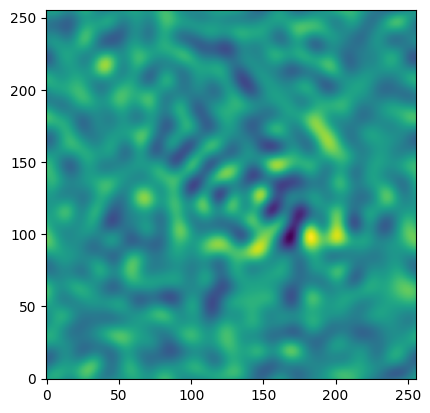

In [35]:
plt.figure()
plt.imshow(v[:, :, 128], origin="lower")

plt.show()

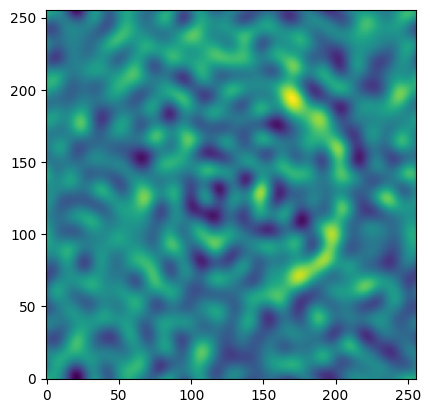

In [39]:
plt.figure()
plt.imshow(v_helene[:, :, 128], origin="lower")

plt.show()